# ARTI406 - Assignment 1  
# Exploratory Data Analysis (EDA): Sleep Health and Lifestyle Dataset

This notebook includes:
- dataset loading
- dataset overview
- data cleaning with explanations
- before and after views of the data
- visualizations with chart justifications
- written insights and conclusion


## 1. Import Libraries and Load Dataset

The analysis begins by loading the libraries needed for data inspection, cleaning, and visualization.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

df = pd.read_csv("Sleep_Health_and_Lifestyle_Dataset.csv")
print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 2. Dataset Overview

This section gives a first look at the structure of the dataset, the data types, and missing values.  
These outputs also serve as the **before-cleaning view** required in the assignment.


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (374, 13)

Columns:
['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']

Data types:
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

Missing values:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category       

### Before Cleaning: First Rows

The table below shows the raw dataset before any cleaning steps were applied.


In [3]:
df.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


## 3. Data Cleaning and Why It Was Needed

The data cleaning was necessary because the raw dataset had issues that would affect analysis quality:

1. **Missing values in `Sleep Disorder`** were filled with `None` because an empty value most likely means the person has no diagnosed disorder.
2. **BMI labels were standardized** because both `Normal` and `Normal Weight` describe the same category. Keeping both would create inconsistent results.
3. **Blood pressure was split into two numeric columns** because storing it as text makes analysis harder. Separating it into systolic and diastolic values allows better quantitative analysis.

These steps improve consistency, readability, and accuracy in the later charts.


In [4]:
eda_df = df.copy()

eda_df["Sleep Disorder"] = eda_df["Sleep Disorder"].fillna("None")
eda_df["BMI Category"] = eda_df["BMI Category"].replace({"Normal Weight": "Normal"})

bp_split = eda_df["Blood Pressure"].str.split("/", expand=True)
eda_df["Systolic BP"] = bp_split[0].astype(int)
eda_df["Diastolic BP"] = bp_split[1].astype(int)

print("Cleaning completed.")

Cleaning completed.


## 4. After Cleaning

The outputs below show the dataset after cleaning.  
These serve as the **after-cleaning view** requested in the assignment.


In [5]:
print("Missing values after cleaning:")
print(eda_df.isnull().sum())
print("\nUpdated columns:")
print(eda_df.columns.tolist())

Missing values after cleaning:
Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Systolic BP                0
Diastolic BP               0
dtype: int64

Updated columns:
['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder', 'Systolic BP', 'Diastolic BP']


In [6]:
eda_df.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia,140,90
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia,140,90
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None,120,80
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None,120,80
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None,120,80


## 5. Summary Statistics

Summary statistics provide a quick numeric description of the dataset and help identify general patterns in the sample.


In [7]:
eda_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Person ID,374.0,NaN,NaN,NaN,187.5,108.108742,1.0,94.25,187.5,280.75,374.0
Gender,374,2,Male,189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,374.0,NaN,NaN,NaN,42.184492,8.673133,27.0,35.25,43.0,50.0,59.0
Occupation,374,11,Nurse,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep Duration,374.0,NaN,NaN,NaN,7.132086,0.795657,5.8,6.4,7.2,7.8,8.5
Quality of Sleep,374.0,NaN,NaN,NaN,7.312834,1.196956,4.0,6.0,7.0,8.0,9.0
Physical Activity Level,374.0,NaN,NaN,NaN,59.171123,20.830804,30.0,45.0,60.0,75.0,90.0
Stress Level,374.0,NaN,NaN,NaN,5.385027,1.774526,3.0,4.0,5.0,7.0,8.0
BMI Category,374,3,Normal,216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood Pressure,374,25,130/85,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Visualizations and Insights

Each plot below includes:
- why this chart type was chosen
- what trend it was used to show
- the insight learned from the chart


### Plot 1: Distribution of Numeric Features

A **histogram** was chosen because it is useful for showing the distribution of numeric variables such as age, sleep duration, and stress level.

**Insight:** The variables have different spreads and concentrations, showing that some health measures vary more than others across individuals.


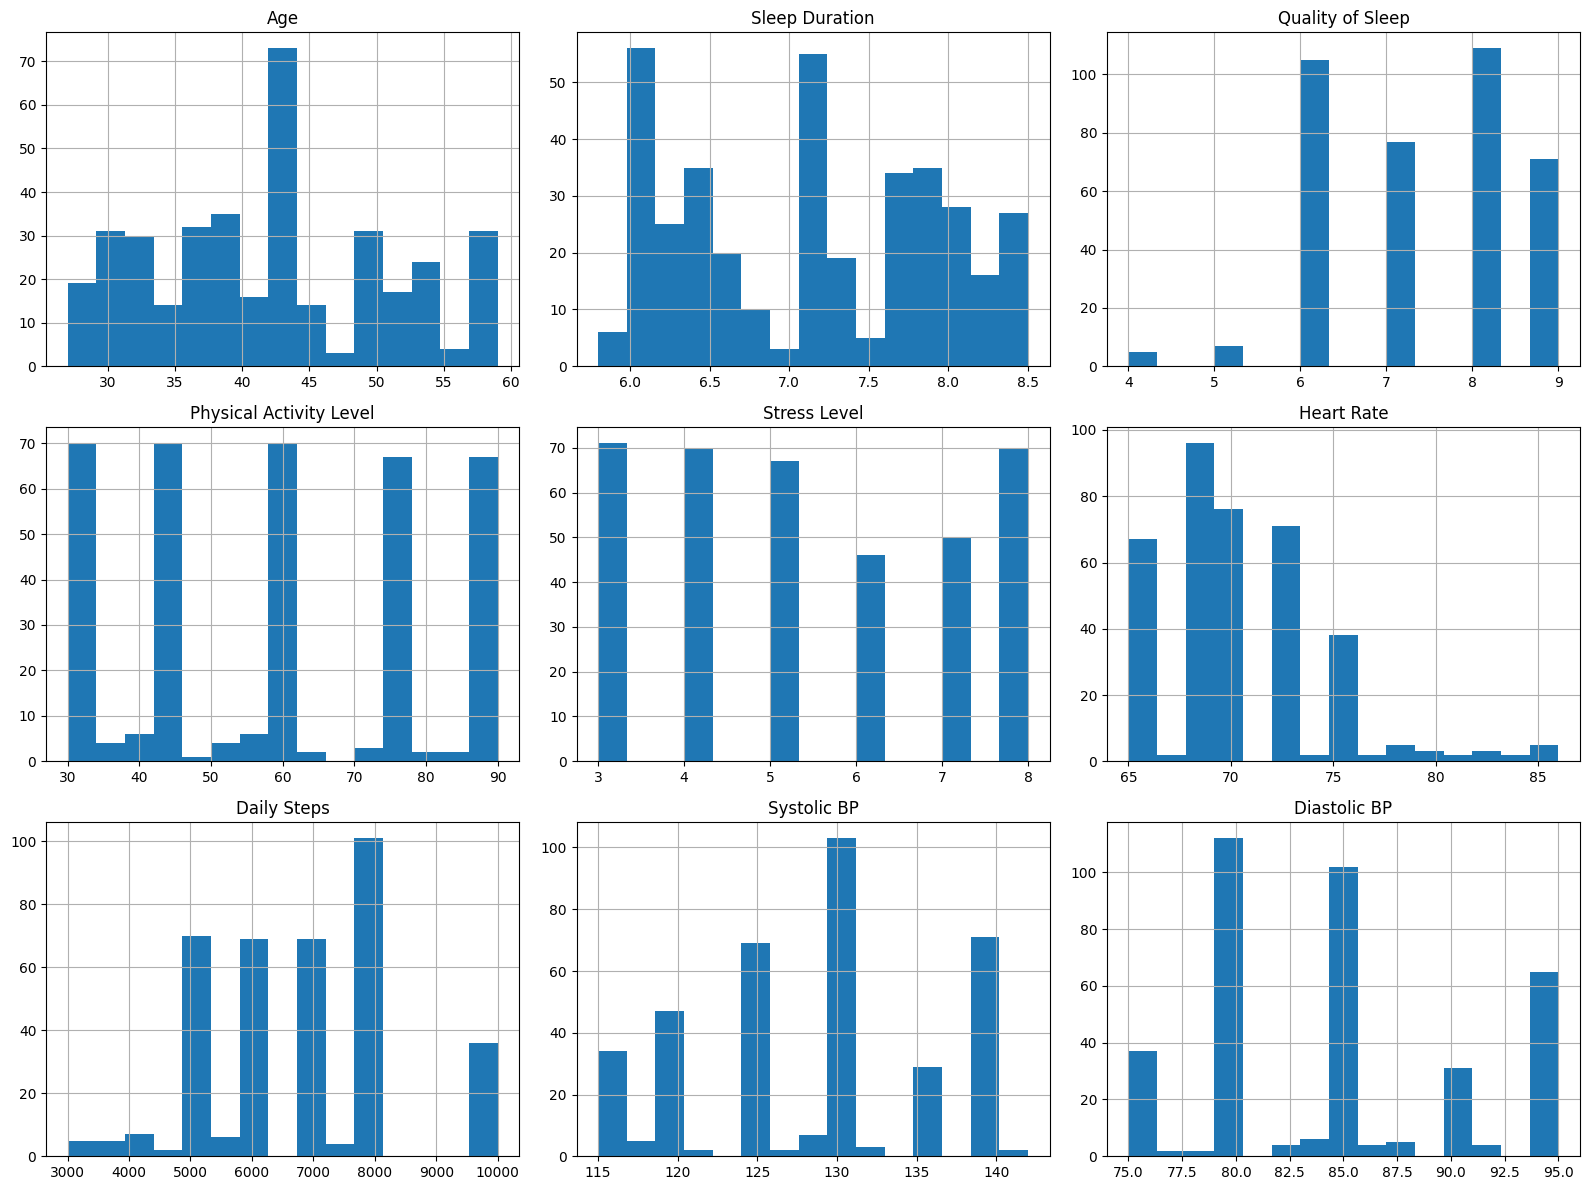

In [8]:
numeric_cols = [
    "Age", "Sleep Duration", "Quality of Sleep", "Physical Activity Level",
    "Stress Level", "Heart Rate", "Daily Steps", "Systolic BP", "Diastolic BP"
]

eda_df[numeric_cols].hist(bins=15, figsize=(16, 12))
plt.tight_layout()
plt.show()

### Plot 2: Gender Distribution

A **bar chart** was chosen because gender is a categorical variable and bar charts clearly compare category counts.

**Insight:** This chart shows whether the dataset is relatively balanced across genders, which matters for fair comparison.


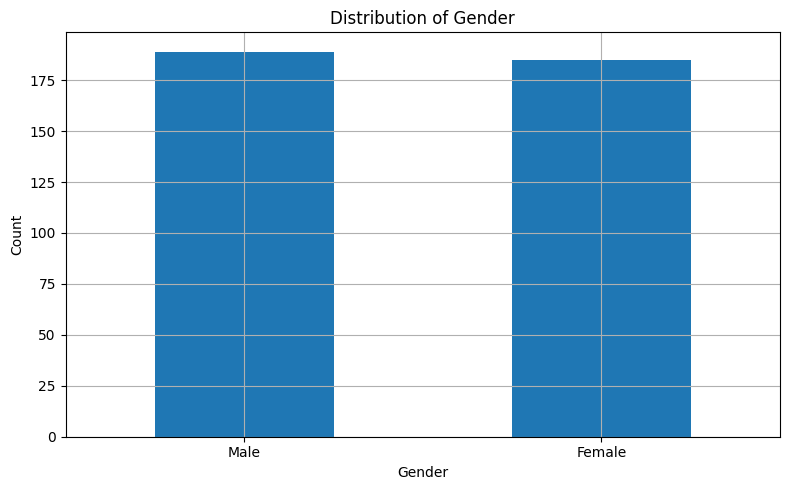

In [9]:
eda_df["Gender"].value_counts().plot(kind="bar")
plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Plot 3: Occupation Distribution

A **bar chart** was chosen because occupation is categorical and the goal is to compare how many records belong to each profession.

**Insight:** Some occupations appear more often than others, which is important when interpreting averages by job type.


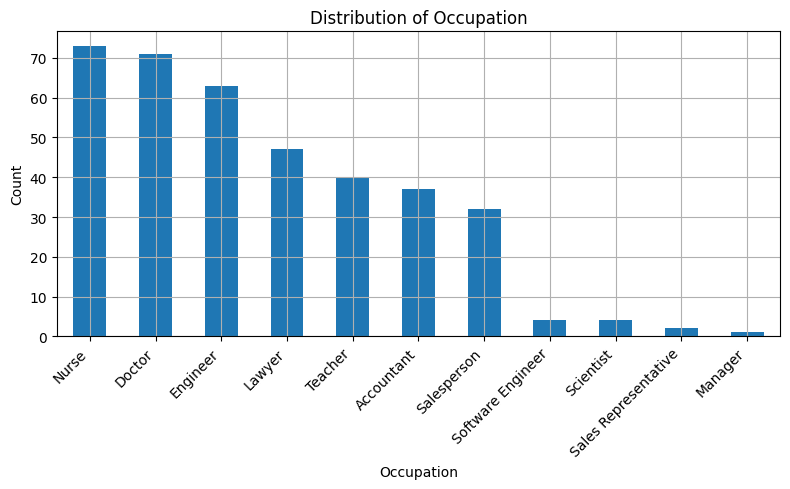

In [10]:
eda_df["Occupation"].value_counts().plot(kind="bar")
plt.title("Distribution of Occupation")
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Plot 4: BMI Category Distribution

A **bar chart** was chosen because BMI category is categorical and this chart compares the sizes of the groups clearly.

**Insight:** The chart shows how body weight categories are distributed and helps prepare for comparing BMI with sleep outcomes.


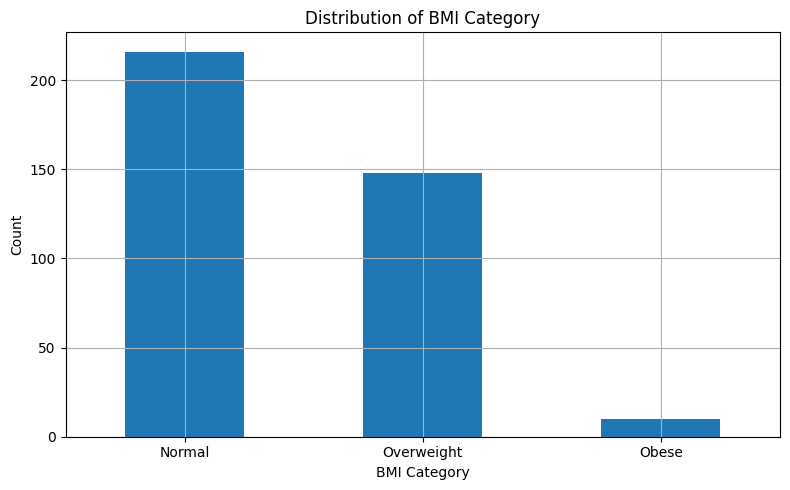

In [11]:
eda_df["BMI Category"].value_counts().plot(kind="bar")
plt.title("Distribution of BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Plot 5: Average Sleep Duration by Occupation

A **bar chart of averages** was chosen because it clearly compares mean sleep duration across occupations.

**Insight:** Sleep duration varies by profession, which suggests that work schedule and job demands may influence rest.


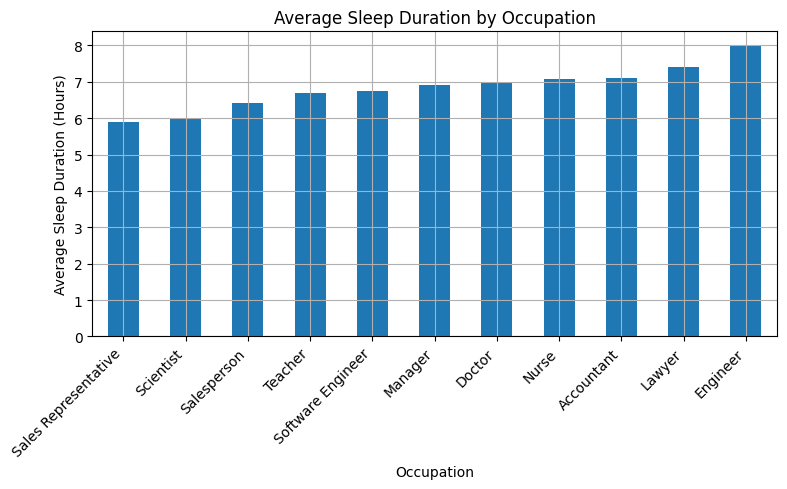

In [12]:
sleep_by_occupation = eda_df.groupby("Occupation")["Sleep Duration"].mean().sort_values()
sleep_by_occupation.plot(kind="bar")
plt.title("Average Sleep Duration by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Average Sleep Duration (Hours)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Plot 6: Average Quality of Sleep by BMI Category

A **bar chart of averages** was chosen because it is effective for comparing the average sleep quality score across BMI groups.

**Insight:** The chart suggests that sleep quality may differ between BMI categories, which could be relevant in health analysis.


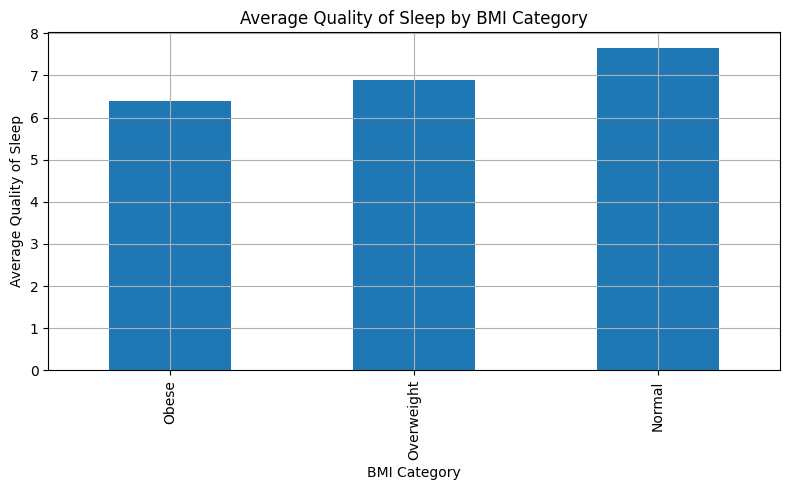

In [13]:
quality_by_bmi = eda_df.groupby("BMI Category")["Quality of Sleep"].mean().sort_values()
quality_by_bmi.plot(kind="bar")
plt.title("Average Quality of Sleep by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Average Quality of Sleep")
plt.tight_layout()
plt.show()

### Plot 7: Stress Level vs Quality of Sleep

A **scatter plot** was chosen because both variables are numeric, and scatter plots are ideal for checking relationships between two continuous variables.

**Insight:** Higher stress generally appears to be associated with lower sleep quality.


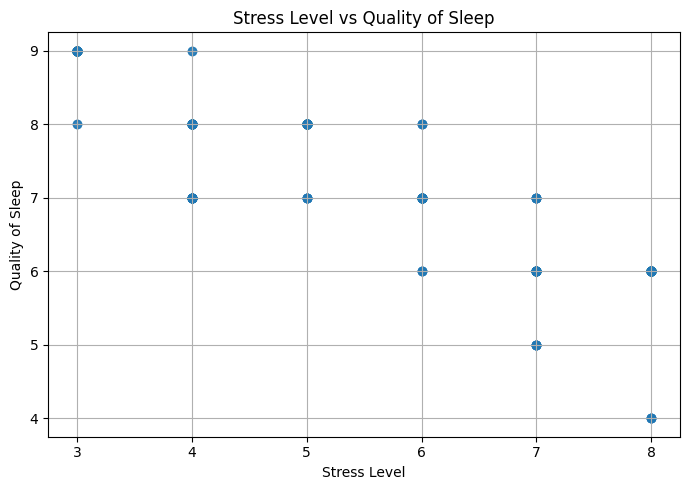

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(eda_df["Stress Level"], eda_df["Quality of Sleep"], alpha=0.7)
plt.title("Stress Level vs Quality of Sleep")
plt.xlabel("Stress Level")
plt.ylabel("Quality of Sleep")
plt.tight_layout()
plt.show()

### Plot 8: Physical Activity Level vs Daily Steps

A **scatter plot** was chosen because both variables are numeric and this chart helps show whether they increase together.

**Insight:** The chart shows a positive relationship, meaning people with higher activity levels tend to take more steps.


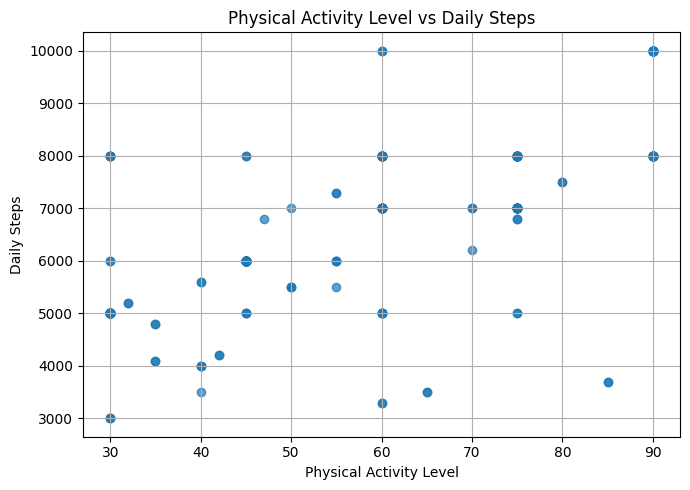

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(eda_df["Physical Activity Level"], eda_df["Daily Steps"], alpha=0.7)
plt.title("Physical Activity Level vs Daily Steps")
plt.xlabel("Physical Activity Level")
plt.ylabel("Daily Steps")
plt.tight_layout()
plt.show()

### Plot 9: Correlation Matrix

A **correlation matrix** was chosen because it summarizes linear relationships among several numeric features at once.

**Insight:** This plot helps identify which lifestyle factors are most strongly related to sleep outcomes and can guide future predictive modeling.


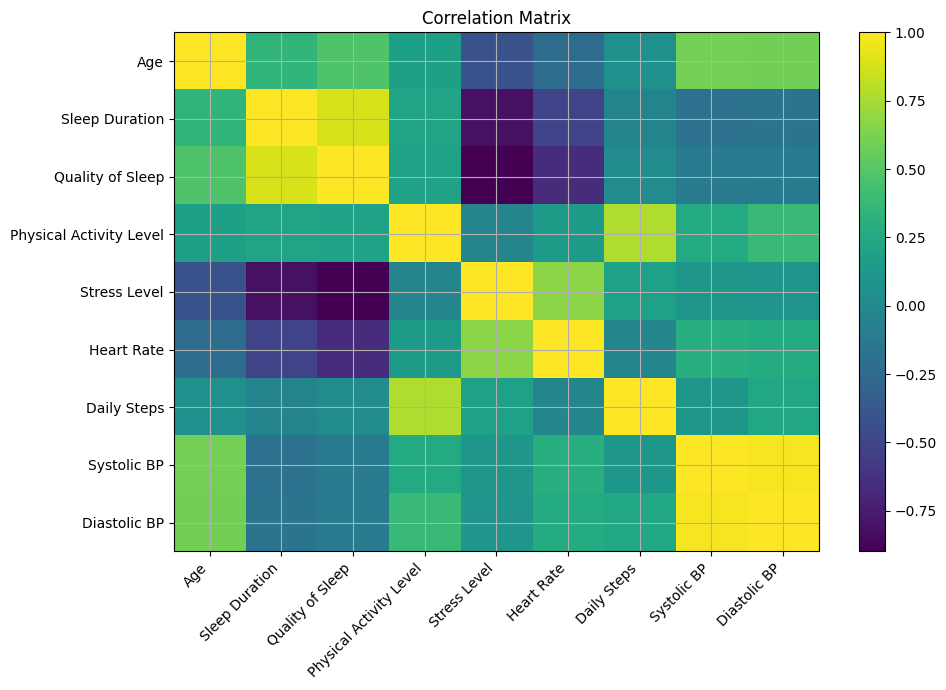

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic BP,Diastolic BP
Age,1.000000,0.344709,0.473734,0.178993,-0.422344,-0.225606,0.057973,0.605878,0.593839
Sleep Duration,0.344709,1.000000,0.883213,0.212360,-0.811023,-0.516455,-0.039533,-0.180406,-0.166570
Quality of Sleep,0.473734,0.883213,1.000000,0.192896,-0.898752,-0.659865,0.016791,-0.121632,-0.110151
Physical Activity Level,0.178993,0.212360,0.192896,1.000000,-0.034134,0.136971,0.772723,0.265416,0.382651
Stress Level,-0.422344,-0.811023,-0.898752,-0.034134,1.000000,0.670026,0.186829,0.102818,0.091811
Heart Rate,-0.225606,-0.516455,-0.659865,0.136971,0.670026,1.000000,-0.030309,0.294143,0.271092
Daily Steps,0.057973,-0.039533,0.016791,0.772723,0.186829,-0.030309,1.000000,0.103342,0.241986
Systolic BP,0.605878,-0.180406,-0.121632,0.265416,0.102818,0.294143,0.103342,1.000000,0.972885
Diastolic BP,0.593839,-0.166570,-0.110151,0.382651,0.091811,0.271092,0.241986,0.972885,1.000000


In [16]:
corr = eda_df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

corr

### Plot 10: Sleep Disorder Distribution

A **bar chart** was chosen because sleep disorder is a categorical variable and the chart clearly compares the frequency of each disorder category.

**Insight:** Most people fall into the `None` category, while fewer individuals report insomnia or sleep apnea.


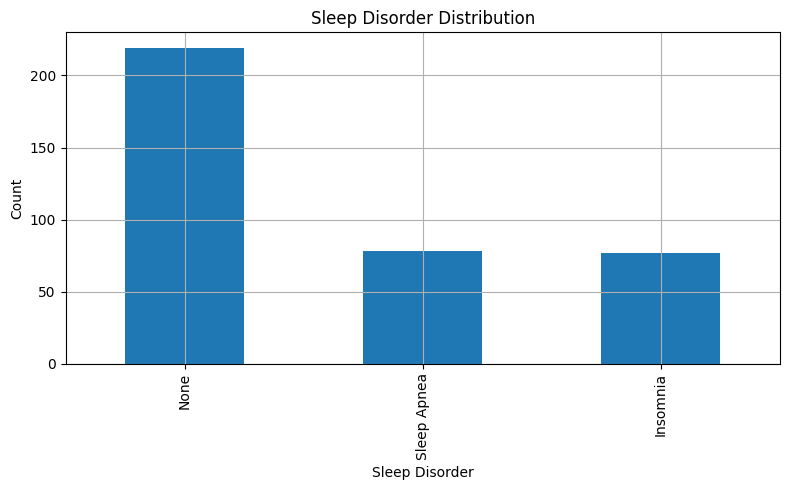

In [17]:
eda_df["Sleep Disorder"].value_counts().plot(kind="bar")
plt.title("Sleep Disorder Distribution")
plt.xlabel("Sleep Disorder")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 7. Sleep Disorder Comparison Table

The table below compares average sleep and health indicators for each sleep disorder category.  
It supports the visual findings with grouped numeric evidence.


In [18]:
sleep_disorder_summary = eda_df.groupby("Sleep Disorder")[
    ["Sleep Duration", "Quality of Sleep", "Stress Level", "Heart Rate", "Daily Steps"]
].mean().round(2)

sleep_disorder_summary

,Sleep Duration,Quality of Sleep,Stress Level,Heart Rate,Daily Steps
Sleep Disorder,,,,,
Insomnia,6.59,6.53,5.87,70.47,5901.30
None,7.36,7.63,5.11,69.02,6852.97
Sleep Apnea,7.03,7.21,5.67,73.09,7619.23


## 8. Expanded Key Insights

1. Missing values in `Sleep Disorder` likely represented no diagnosed condition, so replacing them with `None` made the dataset more meaningful.
2. Standardizing BMI labels prevented the same category from appearing under two names.
3. Stress level appears to be one of the most important factors affecting sleep quality.
4. Occupation seems to influence average sleep duration, which may reflect different work routines and stress patterns.
5. Physical activity level and daily steps move together, which supports the internal consistency of the dataset.
6. People with sleep disorders differ from those with no disorder in sleep quality and related health indicators.
7. Employers and health professionals could use this kind of analysis to identify groups that may benefit from stress reduction or wellness support.


## 9. Conclusion

This exploratory data analysis shows that sleep health is linked to multiple lifestyle and health-related variables, especially stress, physical activity, occupation, and BMI.

The notebook also demonstrates why data cleaning matters before analysis. Missing values, inconsistent labels, and text-based measurements can reduce the clarity of charts and summaries if they are not handled properly.

Overall, this dataset is suitable for:
- exploratory analysis
- health trend interpretation
- comparison between groups
- future machine learning tasks such as sleep disorder prediction
